# Stage 2d: Shortcut Auditing — DeBERTa-v3-base (Frozen + Fine-tuned)

**Sanity check:** replicate the shortcut probing pipeline on a model from a genuinely different architecture family.

**Model:** `microsoft/deberta-v3-base`
- Architecture: **disentangled attention** — content and position information are encoded in separate attention matrices, unlike BERT/RoBERTa's joint QKV attention
- Pretraining objective: **replaced-token detection** (ELECTRA-style discriminator), not masked-language modelling
- Tokenizer: **SentencePiece unigram** (not BPE), different vocabulary from RoBERTa/MentalRoBERTa
- Consistently outperforms BERT/RoBERTa-base on GLUE/SuperGLUE benchmarks
- 12 transformer layers, 768 hidden dim, ~184M parameters

**Why this is a useful sanity check:**
If the finding — fine-tuning integrates shortcuts into a compressed gender representation while
making individual features less linearly decodable — holds here, it is architecture-agnostic.
If it doesn't, the effect may be specific to the RoBERTa pretraining regime.

**Structure:** Part A (frozen) → Part B (fine-tuned), both in one notebook.
Outputs → `data/stage2_deberta/frozen/` and `data/stage2_deberta/finetuned/`

In [ ]:
import os, json, warnings, subprocess
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Single-GPU run: pin to the GPU with the most free memory BEFORE torch inits CUDA.
# (4-GPU DataParallel was the bottleneck — single GPU + fp16 + big batch is faster
#  for a model this size. Must restart the kernel for this to take effect.)
if 'CUDA_VISIBLE_DEVICES' not in os.environ:
    try:
        free = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.free', '--format=csv,noheader,nounits']
        ).decode().split()
        best = max(range(len(free)), key=lambda i: int(free[i]))
        os.environ['CUDA_VISIBLE_DEVICES'] = str(best)
        print(f"Pinned to GPU {best} ({free[best]} MiB free)")
    except Exception as e:
        print(f"GPU auto-select skipped ({e}); using default visibility")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, r2_score, f1_score
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset
import shap

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

MODEL_NAME   = 'microsoft/deberta-v3-base'
MAX_LEN      = 256
BATCH_SIZE   = 64   # frozen [CLS] extraction (inference, no_grad)

OUT_ROOT     = 'data/stage2_deberta'
OUT_FROZEN   = f'{OUT_ROOT}/frozen'
OUT_FT       = f'{OUT_ROOT}/finetuned'
FT_MODEL_DIR = f'{OUT_ROOT}/ft_model'
for d in [OUT_FROZEN, OUT_FT, FT_MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

with open('data/stage1/stage1_results.json') as f:
    stage1 = json.load(f)

SHORTCUT_FEATURES = stage1['shortcut_features']
CONTROL_FEATURES  = stage1['passed_controls']
ALL_18_FEATURES   = stage1['all_18_features']
SHORTCUT_META     = stage1['shortcut_meta']
PROBE_FEATURES    = SHORTCUT_FEATURES + CONTROL_FEATURES

print(f"Shortcuts ({len(SHORTCUT_FEATURES)}): {SHORTCUT_FEATURES}")
print(f"Controls  ({len(CONTROL_FEATURES)}): {CONTROL_FEATURES}")

: 

In [2]:
df = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df['text'] = df['text'].fillna('')

GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'
if 'binary_label' not in df.columns:
    df['binary_label'] = (~df['TID'].str.contains('control')).astype(int)

mf_mask    = df[GENDER_COL].isin(['male', 'female'])
df_mf      = df[mf_mask].copy()
df_mf['gender_bin'] = (df_mf[GENDER_COL] == 'female').astype(int)
mf_idx_arr = np.where(mf_mask.values)[0]

print(f"Loaded {len(df):,} rows | Label dist: {df['binary_label'].value_counts().to_dict()}")

def build_targets(df, PROBE_FEATURES, SHORTCUT_FEATURES, GENDER_COL, mf_idx_arr):
    targets = {}
    for feat in PROBE_FEATURES:
        vals = df[feat].fillna(0).values.astype(float)
        targets[feat] = (vals > np.median(vals)).astype(int)
    targets['gender'] = (df.iloc[mf_idx_arr][GENDER_COL] == 'female').astype(int).values
    targets['binary_label'] = df['binary_label'].values.astype(int)
    return targets

targets = build_targets(df, PROBE_FEATURES, SHORTCUT_FEATURES, GENDER_COL, mf_idx_arr)

Loaded 32,200 rows | Label dist: {0: 22601, 1: 9599}


In [3]:
# ── Shared utility functions (identical to 02c) ───────────────────────────────

def extract_cls_embeddings(texts, model, tok, batch_size=BATCH_SIZE):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 20 == 0:
            print(f"  Batch {i//batch_size+1}/{(len(texts)-1)//batch_size+1}", end='\r')
    print()
    return np.vstack(all_embs)


def extract_cls_all_layers(texts, model, tok, batch_size=BATCH_SIZE):
    # unwrap DataParallel to read config
    cfg = model.module.config if isinstance(model, nn.DataParallel) else model.config
    n_layers = cfg.num_hidden_layers
    layer_embs = [[] for _ in range(n_layers + 1)]
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for li in range(n_layers + 1):
            layer_embs[li].append(out.hidden_states[li][:, 0, :].cpu().numpy())
        if (i // batch_size) % 25 == 0:
            print(f"  Batch {i//batch_size+1}/{(len(texts)-1)//batch_size+1}", end='\r')
    print()
    return [np.vstack(le) for le in layer_embs]


def gpu_probe_auc(X_np, y_np, n_splits=5, lr=0.01, epochs=200, batch_size=2048):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, te_idx in cv.split(X_np, y_np):
        X_tr = torch.tensor(X_np[tr_idx], dtype=torch.float32, device=DEVICE)
        y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32, device=DEVICE)
        X_te = torch.tensor(X_np[te_idx], dtype=torch.float32, device=DEVICE)
        y_te = y_np[te_idx]
        m = nn.Linear(X_tr.shape[1], 1).to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.BCEWithLogitsLoss()
        m.train()
        n = len(X_tr)
        for _ in range(epochs):
            perm = torch.randperm(n, device=DEVICE)
            for s in range(0, n, batch_size):
                idx = perm[s:s+batch_size]
                loss = loss_fn(m(X_tr[idx]).squeeze(-1), y_tr[idx])
                opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            probs = torch.sigmoid(m(X_te).squeeze(-1)).cpu().numpy()
        aucs.append(roc_auc_score(y_te, probs))
    return np.mean(aucs), np.std(aucs)


def run_probing(X_cls, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
                GENDER_COL, mf_mask, df_mf):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cls)
    probe_results = []
    y_strat = df['binary_label'].values
    for feat in PROBE_FEATURES:
        y_cont = df[feat].fillna(0).values.astype(float)
        role = 'shortcut' if feat in SHORTCUT_FEATURES else 'control'
        ridge = Ridge(alpha=1.0)
        cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        r2s = []
        for tr, te in cv5.split(X_scaled, y_strat):
            ridge.fit(X_scaled[tr], y_cont[tr])
            r2s.append(r2_score(y_cont[te], ridge.predict(X_scaled[te])))
        y_bin = (y_cont > np.median(y_cont)).astype(int)
        clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
        aucs = cross_val_score(clf, X_scaled, y_bin,
                               cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                               scoring='roc_auc')
        probe_results.append({'feature': feat, 'role': role,
                               'probe_R2': np.mean(r2s),
                               'probe_AUC_median_split': aucs.mean(),
                               'probe_AUC_std': aucs.std()})
        print(f"  [{role:8s}] {feat:22s}  R²={np.mean(r2s):.4f}  AUC={aucs.mean():.3f}±{aucs.std():.3f}")
    mf_idx = df.index[mf_mask].tolist()
    X_mf = X_scaled[mf_idx]
    y_g = df_mf['gender_bin'].values
    aucs_g = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                              X_mf, y_g,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='roc_auc')
    print(f"  {'gender (m/f)':22s}  AUC={aucs_g.mean():.3f}±{aucs_g.std():.3f}")
    y_l = df['binary_label'].values
    aucs_l = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                              X_scaled, y_l,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='roc_auc')
    print(f"  {'binary_label':22s}  AUC={aucs_l.mean():.3f}±{aucs_l.std():.3f}")
    return pd.DataFrame(probe_results), aucs_g, aucs_l, X_scaled


def run_layerwise_probing(all_layer_cls, targets, PROBE_FEATURES, SHORTCUT_FEATURES,
                          CONTROL_FEATURES, mf_idx_arr):
    n_layers = len(all_layer_cls)
    layer_names = ['Emb'] + [f'L{i}' for i in range(1, n_layers)]
    results = []
    for li in range(n_layers):
        X_sc = StandardScaler().fit_transform(all_layer_cls[li])
        for t_name, y in targets.items():
            X_probe = X_sc[mf_idx_arr] if t_name == 'gender' else X_sc
            auc_m, auc_s = gpu_probe_auc(X_probe, y)
            role = ('shortcut' if t_name in SHORTCUT_FEATURES
                    else 'control' if t_name in CONTROL_FEATURES
                    else 'meta')
            results.append({'layer': li, 'layer_name': layer_names[li],
                             'target': t_name, 'role': role,
                             'AUC': auc_m, 'AUC_std': auc_s})
        print(f"  Layer {layer_names[li]:4s} done")
    return pd.DataFrame(results), layer_names


def run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL):
    X_all = df[ALL_18_FEATURES].fillna(0).values.astype(float)
    y_all = df['binary_label'].values.astype(int)
    sc18 = StandardScaler()
    X_s = sc18.fit_transform(X_all)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    base_aucs = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                 X_s, y_all, cv=cv, scoring='roc_auc')
    baseline_auc = base_aucs.mean()
    print(f"Baseline (18 features): AUC = {baseline_auc:.4f} ± {base_aucs.std():.4f}")
    abl_results = []
    for feat in SHORTCUT_FEATURES:
        fi = ALL_18_FEATURES.index(feat)
        X_a = X_s.copy(); X_a[:, fi] = 0
        aucs_a = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                  X_a, y_all, cv=cv, scoring='roc_auc')
        drop = baseline_auc - aucs_a.mean()
        abl_results.append({'ablated': feat, 'AUC_after': aucs_a.mean(),
                             'AUC_std': aucs_a.std(), 'AUC_drop': drop,
                             'drop_pct': drop / baseline_auc * 100})
        print(f"  Ablate {feat:25s}: AUC={aucs_a.mean():.4f}  (Δ={drop:+.4f})")
    fi_all = [ALL_18_FEATURES.index(f) for f in SHORTCUT_FEATURES]
    X_a_all = X_s.copy(); X_a_all[:, fi_all] = 0
    aucs_all = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_a_all, y_all, cv=cv, scoring='roc_auc')
    drop_all = baseline_auc - aucs_all.mean()
    print(f"  Ablate ALL: AUC={aucs_all.mean():.4f}  (Δ={drop_all:+.4f})")
    clf_full = LogisticRegression(max_iter=1000, random_state=42)
    clf_full.fit(X_s, y_all)
    genders = df[GENDER_COL].values
    strat_results = []
    for gender in ['male', 'female']:
        g_mask = genders == gender
        X_g = X_s[g_mask]; y_g = y_all[g_mask]
        if len(np.unique(y_g)) < 2: continue
        base_g = roc_auc_score(y_g, clf_full.predict_proba(X_g)[:, 1])
        for feat in SHORTCUT_FEATURES:
            fi = ALL_18_FEATURES.index(feat)
            X_ga = X_g.copy(); X_ga[:, fi] = 0
            abl_g = roc_auc_score(y_g, clf_full.predict_proba(X_ga)[:, 1])
            d = base_g - abl_g
            strat_results.append({'gender': gender, 'ablated': feat,
                                   'baseline_AUC': base_g, 'ablated_AUC': abl_g,
                                   'AUC_drop': d, 'drop_pct': d / base_g * 100})
    return pd.DataFrame(abl_results), pd.DataFrame(strat_results), baseline_auc, aucs_all, drop_all


def plot_probing(probe_df, aucs_g, aucs_l, PROBE_FEATURES, SHORTCUT_FEATURES,
                 CONTROL_FEATURES, title_suffix, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    probe_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']
    probe_aucs = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
                  for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]
    probe_stds = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_std'].values[0]
                  for f in PROBE_FEATURES] + [aucs_g.std(), aucs_l.std()]
    colors = (['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
              + ['#3498db', '#2c3e50'])
    axes[0].barh(range(len(probe_labels)), probe_aucs, xerr=probe_stds,
                 color=colors, edgecolor='white')
    axes[0].set_yticks(range(len(probe_labels)))
    axes[0].set_yticklabels(probe_labels, fontsize=10)
    axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5)
    axes[0].set_xlabel('Probe AUC (5-fold CV)')
    axes[0].set_title(f'[CLS] Linear Probe\n{title_suffix}\n(red=shortcut, green=control)')
    for i, (a, s) in enumerate(zip(probe_aucs, probe_stds)):
        axes[0].text(a+s+0.005, i, f'{a:.3f}', va='center', fontsize=9)
    r2_vals = probe_df['probe_R2'].values
    r2_colors = ['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
    axes[1].barh(range(len(PROBE_FEATURES)), r2_vals, color=r2_colors, edgecolor='white')
    axes[1].set_yticks(range(len(PROBE_FEATURES)))
    axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
    axes[1].set_xlabel('Regression Probe R²')
    axes[1].set_title(f'[CLS] → Feature Value Recovery\n{title_suffix}')
    for i, r2 in enumerate(r2_vals):
        axes[1].text(max(r2,0)+0.002, i, f'{r2:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved → {save_path}")


def plot_layerwise(layer_probe_df, layer_names, SHORTCUT_FEATURES, CONTROL_FEATURES,
                   all_targets_ordered, title_suffix, save_prefix):
    n_layers = len(layer_names)
    layers_x = np.arange(n_layers)
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    cmap_sc   = plt.cm.Set1(np.linspace(0, 0.7, len(SHORTCUT_FEATURES)))
    row_g = layer_probe_df[layer_probe_df['target']=='gender'].sort_values('layer')
    row_l = layer_probe_df[layer_probe_df['target']=='binary_label'].sort_values('layer')
    for i, feat in enumerate(SHORTCUT_FEATURES):
        row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
        axes[0].plot(layers_x, row['AUC'].values, 'o-', color=cmap_sc[i],
                     label=feat, linewidth=2, markersize=5)
    axes[0].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender', linewidth=2.5)
    axes[0].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label', linewidth=2.5)
    axes[0].axhline(0.5, color='lightgrey', linestyle=':')
    axes[0].set_xticks(layers_x); axes[0].set_xticklabels(layer_names, fontsize=8, rotation=45)
    axes[0].set_ylabel('Probe AUC'); axes[0].set_ylim(0.48, 1.02)
    axes[0].set_title(f'Shortcuts Across Depth\n{title_suffix}', fontweight='bold')
    axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)
    cmap_ctrl = plt.cm.Dark2(np.linspace(0, 0.6, len(CONTROL_FEATURES)))
    for i, feat in enumerate(CONTROL_FEATURES):
        row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
        axes[1].plot(layers_x, row['AUC'].values, 'o-', color=cmap_ctrl[i],
                     label=feat, linewidth=2, markersize=5)
    axes[1].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender', linewidth=2.5)
    axes[1].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label', linewidth=2.5)
    axes[1].axhline(0.5, color='lightgrey', linestyle=':')
    axes[1].set_xticks(layers_x); axes[1].set_xticklabels(layer_names, fontsize=8, rotation=45)
    axes[1].set_ylabel('Probe AUC'); axes[1].set_ylim(0.48, 1.02)
    axes[1].set_title(f'Controls Across Depth\n{title_suffix}', fontweight='bold')
    axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
    deltas, auc_e, auc_f = [], [], []
    for t in all_targets_ordered:
        row = layer_probe_df[layer_probe_df['target']==t].sort_values('layer')
        auc_e.append(row['AUC'].values[0]); auc_f.append(row['AUC'].values[-1])
        deltas.append(row['AUC'].values[-1] - row['AUC'].values[0])
    bar_colors = (['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
                  + ['#3498db', '#2c3e50'])
    axes[2].barh(range(len(all_targets_ordered)), deltas, color=bar_colors, edgecolor='white')
    axes[2].set_yticks(range(len(all_targets_ordered)))
    axes[2].set_yticklabels(all_targets_ordered, fontsize=9)
    axes[2].axvline(0, color='grey', linewidth=0.5)
    axes[2].set_xlabel('ΔAUC (Final − Emb)')
    axes[2].set_title(f'Depth Gain\n{title_suffix}', fontweight='bold')
    for i, (d, ae, af) in enumerate(zip(deltas, auc_e, auc_f)):
        axes[2].text(max(d,0)+0.002, i, f'{ae:.3f}→{af:.3f} (Δ{d:+.3f})', va='center', fontsize=8)
    axes[2].grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_layerwise.png', dpi=150, bbox_inches='tight')
    plt.show()
    hm_data = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')
    hm_data = hm_data.loc[all_targets_ordered, layer_names]
    row_labels = ([f'★ {f}' for f in SHORTCUT_FEATURES] + [f'◇ {f}' for f in CONTROL_FEATURES]
                  + ['■ gender', '■ binary_label'])
    fig, ax = plt.subplots(figsize=(max(10, n_layers), 8))
    im = ax.imshow(hm_data.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(n_layers)); ax.set_xticklabels(layer_names, fontsize=9, rotation=45)
    ax.set_yticks(range(len(all_targets_ordered)))
    ax.set_yticklabels(row_labels, fontsize=10)
    ax.set_title(f'Layer-wise Probing AUC Heatmap\n{title_suffix}', fontsize=12, fontweight='bold')
    for i in range(len(all_targets_ordered)):
        for j in range(n_layers):
            val = hm_data.values[i, j]
            c = 'white' if val > 0.85 or val < 0.55 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=c, fontweight='bold')
    ax.axhline(len(SHORTCUT_FEATURES)-0.5, color='black', linewidth=1.5)
    ax.axhline(len(SHORTCUT_FEATURES)+len(CONTROL_FEATURES)-0.5, color='black', linewidth=1.5)
    plt.colorbar(im, ax=ax, label='Probe AUC', shrink=0.8)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {save_prefix}_layerwise.png + _heatmap.png")


def plot_ablation(ablation_df, strat_df, baseline_auc, drop_all,
                  SHORTCUT_FEATURES, title_suffix, save_path):
    n_short = len(SHORTCUT_FEATURES)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    abl_labels = list(ablation_df['ablated']) + [f'All {n_short} shortcuts']
    abl_drops  = list(ablation_df['AUC_drop']) + [drop_all]
    cmap = plt.cm.Set2(np.linspace(0, 1, n_short+1))
    axes[0].barh(range(len(abl_labels)), abl_drops,
                 color=[cmap[i] for i in range(len(abl_labels))], edgecolor='white')
    axes[0].set_yticks(range(len(abl_labels))); axes[0].set_yticklabels(abl_labels, fontsize=9)
    axes[0].set_xlabel('AUC Drop After Ablation')
    axes[0].set_title(f'Feature Ablation (baseline={baseline_auc:.4f})\n{title_suffix}')
    axes[0].axvline(0, color='grey', linewidth=0.5)
    for i, d in enumerate(abl_drops):
        axes[0].text(max(d,0)+0.0003, i, f'{d:+.4f}', va='center', fontsize=9)
    x = np.arange(n_short); w = 0.35
    m_drops = strat_df[strat_df['gender']=='male'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
    f_drops = strat_df[strat_df['gender']=='female'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
    axes[1].bar(x-w/2, m_drops, w, label='Male',   color='#3498db', alpha=0.85)
    axes[1].bar(x+w/2, f_drops, w, label='Female', color='#e74c3c', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
    axes[1].set_ylabel('AUC Drop')
    axes[1].set_title(f'Gender-Stratified Ablation\n{title_suffix}')
    axes[1].legend(); axes[1].axhline(0, color='grey', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show(); print(f"Saved → {save_path}")


print("Utility functions defined.")

Utility functions defined.


---
# Part A — Frozen DeBERTa-v3-base

Note: DeBERTa-v3 uses a SentencePiece tokenizer and disentangled attention.
The `[CLS]` token (position 0 of `last_hidden_state`) is used for probing,
consistent with all previous notebooks.

In [4]:
print(f"Loading frozen {MODEL_NAME} …")
tokenizer_frozen = AutoTokenizer.from_pretrained(MODEL_NAME)
# deberta-v3-base config has torch_dtype=float16; force fp32 so frozen [CLS]
# embeddings match the fp32 precision used in the RoBERTa notebook (02c).
encoder_frozen   = AutoModel.from_pretrained(MODEL_NAME, dtype=torch.float32).to(DEVICE).eval()

n_params = sum(p.numel() for p in encoder_frozen.parameters()) / 1e6
n_layers = encoder_frozen.config.num_hidden_layers
print(f"  Parameters: {n_params:.1f}M  |  Transformer layers: {n_layers}")
print(f"  Tokenizer type: {type(tokenizer_frozen).__name__}")
print(f"  Vocab size: {tokenizer_frozen.vocab_size}")

if N_GPUS > 1:
    encoder_frozen = nn.DataParallel(encoder_frozen)
    print(f"  Wrapped in DataParallel across {N_GPUS} GPUs")

Loading frozen microsoft/deberta-v3-base …


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Parameters: 183.8M  |  Transformer layers: 12
  Tokenizer type: DebertaV2Tokenizer
  Vocab size: 128000
  Wrapped in DataParallel across 4 GPUs


In [5]:
print(f"Extracting [CLS] embeddings (frozen) for {len(df):,} posts …")
X_cls_frozen = extract_cls_embeddings(df['text'].tolist(), encoder_frozen, tokenizer_frozen)
print(f"Shape: {X_cls_frozen.shape}")
np.save(f'{OUT_FROZEN}/cls_embeddings.npy', X_cls_frozen)
print(f"Saved → {OUT_FROZEN}/cls_embeddings.npy")

Extracting [CLS] embeddings (frozen) for 32,200 posts …
  Batch 501/504
Shape: (32200, 768)
Saved → data/stage2_deberta/frozen/cls_embeddings.npy


## A1 — Probing Classifiers (Frozen)

In [6]:
print("Running probing on frozen DeBERTa-v3 [CLS] …")
probe_df_frozen, aucs_g_frozen, aucs_l_frozen, _ = run_probing(
    X_cls_frozen, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
    GENDER_COL, mf_mask, df_mf
)
probe_df_frozen

Running probing on frozen DeBERTa-v3 [CLS] …
  [shortcut] fp_singular             R²=0.7656  AUC=0.948±0.003
  [shortcut] analytic                R²=0.7140  AUC=0.927±0.002
  [shortcut] body_health             R²=0.4252  AUC=0.810±0.002
  [shortcut] post_length             R²=0.4802  AUC=0.998±0.000
  [shortcut] self_ref_rumination     R²=0.2753  AUC=0.894±0.003
  [shortcut] hedge_density           R²=0.3372  AUC=0.804±0.004
  [shortcut] negative_emotion        R²=0.2432  AUC=0.881±0.005
  [shortcut] emotional_feeling       R²=0.3967  AUC=0.812±0.008
  [control ] cogproc                 R²=0.6106  AUC=0.871±0.003
  [control ] clout                   R²=0.5148  AUC=0.887±0.002
  gender (m/f)            AUC=0.864±0.005
  binary_label            AUC=0.798±0.005


,feature,role,probe_R2,probe_AUC_median_split,probe_AUC_std
0,fp_singular,shortcut,0.765645,0.948198,0.003062
1,analytic,shortcut,0.714039,0.926634,0.001683
2,body_health,shortcut,0.425188,0.809715,0.002013
3,post_length,shortcut,0.480176,0.998440,0.000246
4,self_ref_rumination,shortcut,0.275265,0.894236,0.003054
5,hedge_density,shortcut,0.337165,0.804168,0.004346
6,negative_emotion,shortcut,0.243178,0.880798,0.004699
7,emotional_feeling,shortcut,0.396654,0.811918,0.008320
8,cogproc,control,0.610640,0.871032,0.003305
9,clout,control,0.514776,0.887182,0.002431


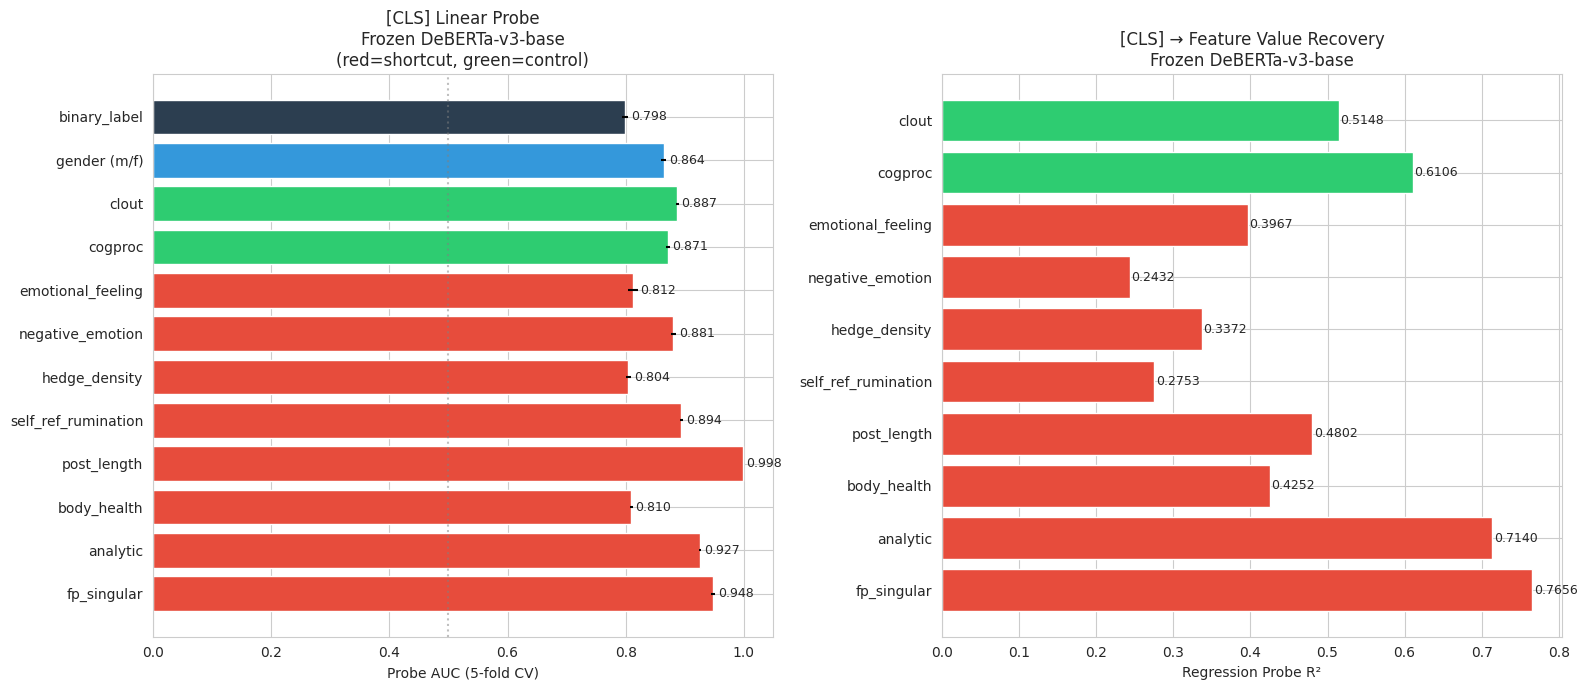

Saved → data/stage2_deberta/frozen/probing_results.png


In [7]:
plot_probing(probe_df_frozen, aucs_g_frozen, aucs_l_frozen,
             PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
             title_suffix='Frozen DeBERTa-v3-base',
             save_path=f'{OUT_FROZEN}/probing_results.png')
probe_df_frozen.to_csv(f'{OUT_FROZEN}/probing_results.csv', index=False)

## A2 — Layer-wise Probing (Frozen)

In [8]:
print(f"Extracting all-layer [CLS] (frozen) for {len(df):,} posts …")
all_layer_cls_frozen = extract_cls_all_layers(df['text'].tolist(), encoder_frozen, tokenizer_frozen)
print(f"Got {len(all_layer_cls_frozen)} layers, shape {all_layer_cls_frozen[0].shape}")

Extracting all-layer [CLS] (frozen) for 32,200 posts …
  Batch 501/504
Got 13 layers, shape (32200, 768)


In [9]:
print("Running layer-wise probing (frozen) …")
layer_probe_df_frozen, layer_names_frozen = run_layerwise_probing(
    all_layer_cls_frozen, targets, PROBE_FEATURES,
    SHORTCUT_FEATURES, CONTROL_FEATURES, mf_idx_arr
)
pivot_f = layer_probe_df_frozen.pivot(index='target', columns='layer_name', values='AUC')
print(pivot_f[layer_names_frozen].round(3).to_string())

Running layer-wise probing (frozen) …
  Layer Emb  done
  Layer L1   done
  Layer L2   done
  Layer L3   done
  Layer L4   done
  Layer L5   done
  Layer L6   done
  Layer L7   done
  Layer L8   done
  Layer L9   done
  Layer L10  done
  Layer L11  done
  Layer L12  done
layer_name           Emb     L1     L2     L3     L4     L5     L6     L7     L8     L9    L10    L11    L12
target                                                                                                      
analytic             0.5  0.941  0.955  0.905  0.924  0.910  0.913  0.899  0.901  0.907  0.894  0.911  0.913
binary_label         0.5  0.771  0.778  0.781  0.782  0.787  0.789  0.787  0.796  0.788  0.788  0.789  0.792
body_health          0.5  0.845  0.849  0.821  0.845  0.845  0.844  0.834  0.830  0.819  0.805  0.803  0.792
clout                0.5  0.882  0.908  0.866  0.857  0.870  0.893  0.888  0.896  0.886  0.875  0.876  0.874
cogproc              0.5  0.849  0.885  0.845  0.860  0.850  0.861  0.853 

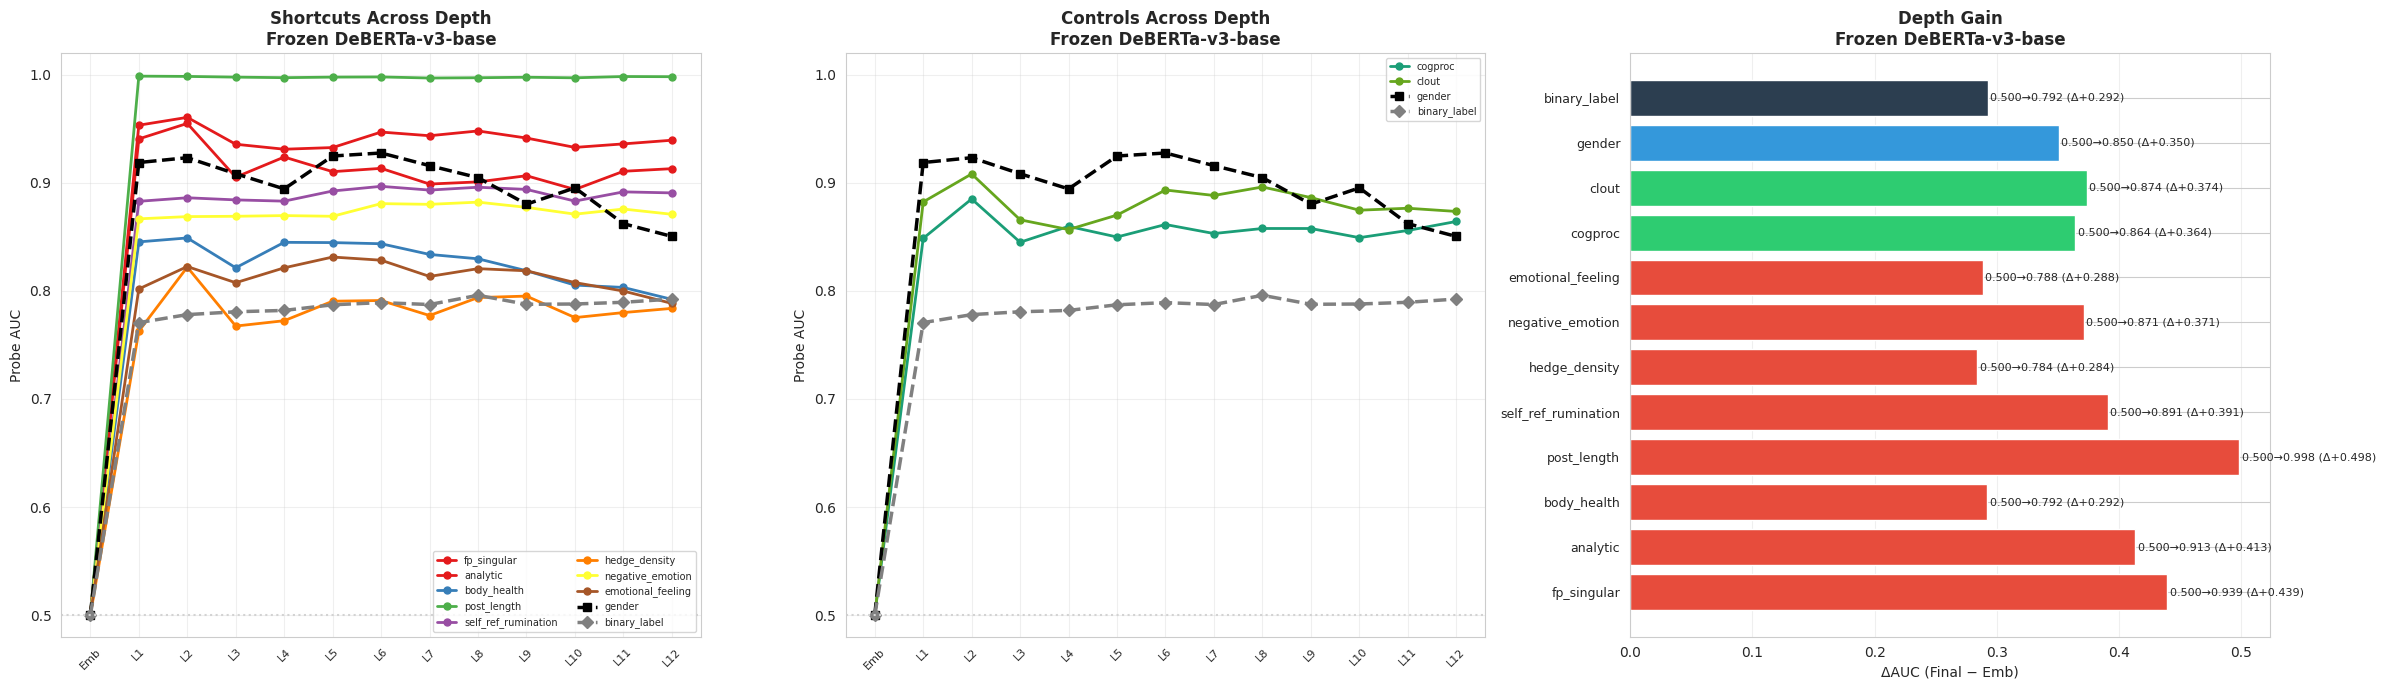

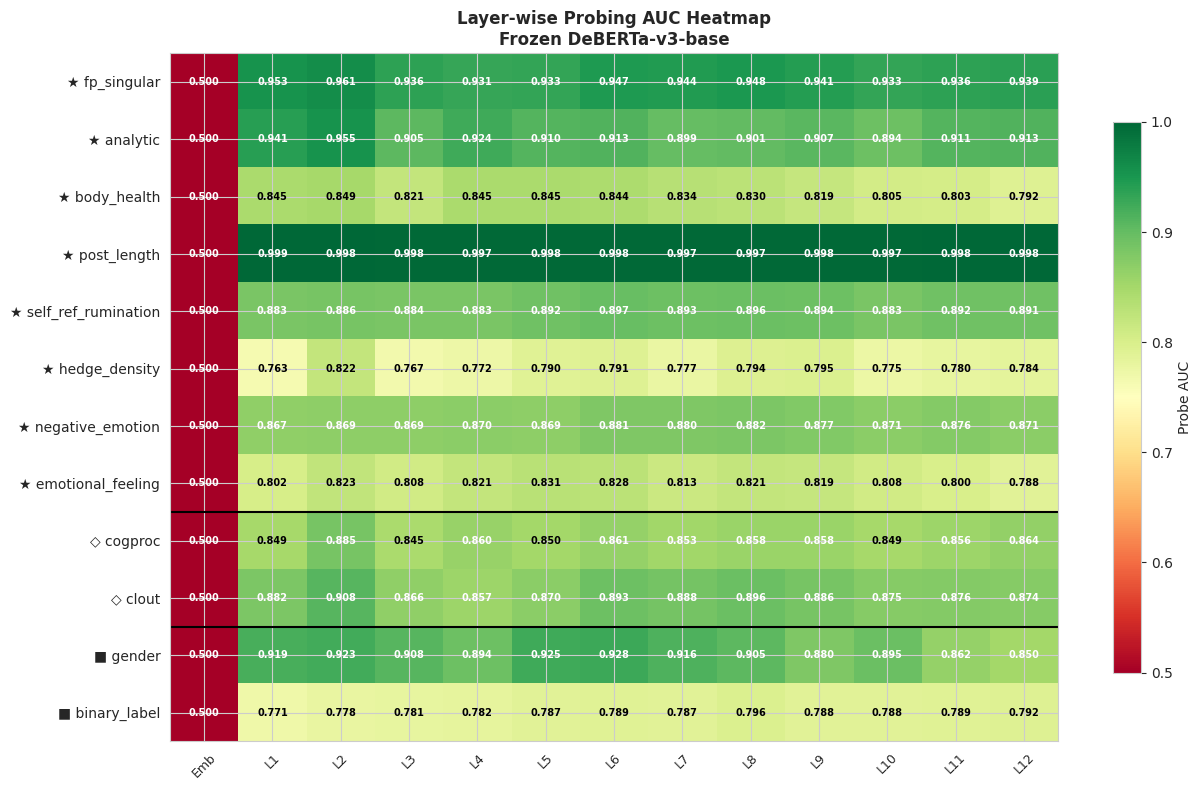

Saved → data/stage2_deberta/frozen/layerwise_layerwise.png + _heatmap.png


In [10]:
all_targets_ordered = SHORTCUT_FEATURES + CONTROL_FEATURES + ['gender', 'binary_label']
plot_layerwise(layer_probe_df_frozen, layer_names_frozen,
               SHORTCUT_FEATURES, CONTROL_FEATURES, all_targets_ordered,
               title_suffix='Frozen DeBERTa-v3-base',
               save_prefix=f'{OUT_FROZEN}/layerwise')
layer_probe_df_frozen.to_csv(f'{OUT_FROZEN}/layerwise_probing.csv', index=False)

## A4 — Feature Ablation (Frozen)

Baseline (18 features): AUC = 0.7214 ± 0.0074
  Ablate fp_singular              : AUC=0.7166  (Δ=+0.0049)
  Ablate analytic                 : AUC=0.7186  (Δ=+0.0028)
  Ablate body_health              : AUC=0.7032  (Δ=+0.0182)
  Ablate post_length              : AUC=0.7173  (Δ=+0.0041)
  Ablate self_ref_rumination      : AUC=0.7215  (Δ=-0.0000)
  Ablate hedge_density            : AUC=0.7215  (Δ=-0.0001)
  Ablate negative_emotion         : AUC=0.7208  (Δ=+0.0006)
  Ablate emotional_feeling        : AUC=0.7214  (Δ=-0.0000)
  Ablate ALL: AUC=0.6503  (Δ=+0.0711)


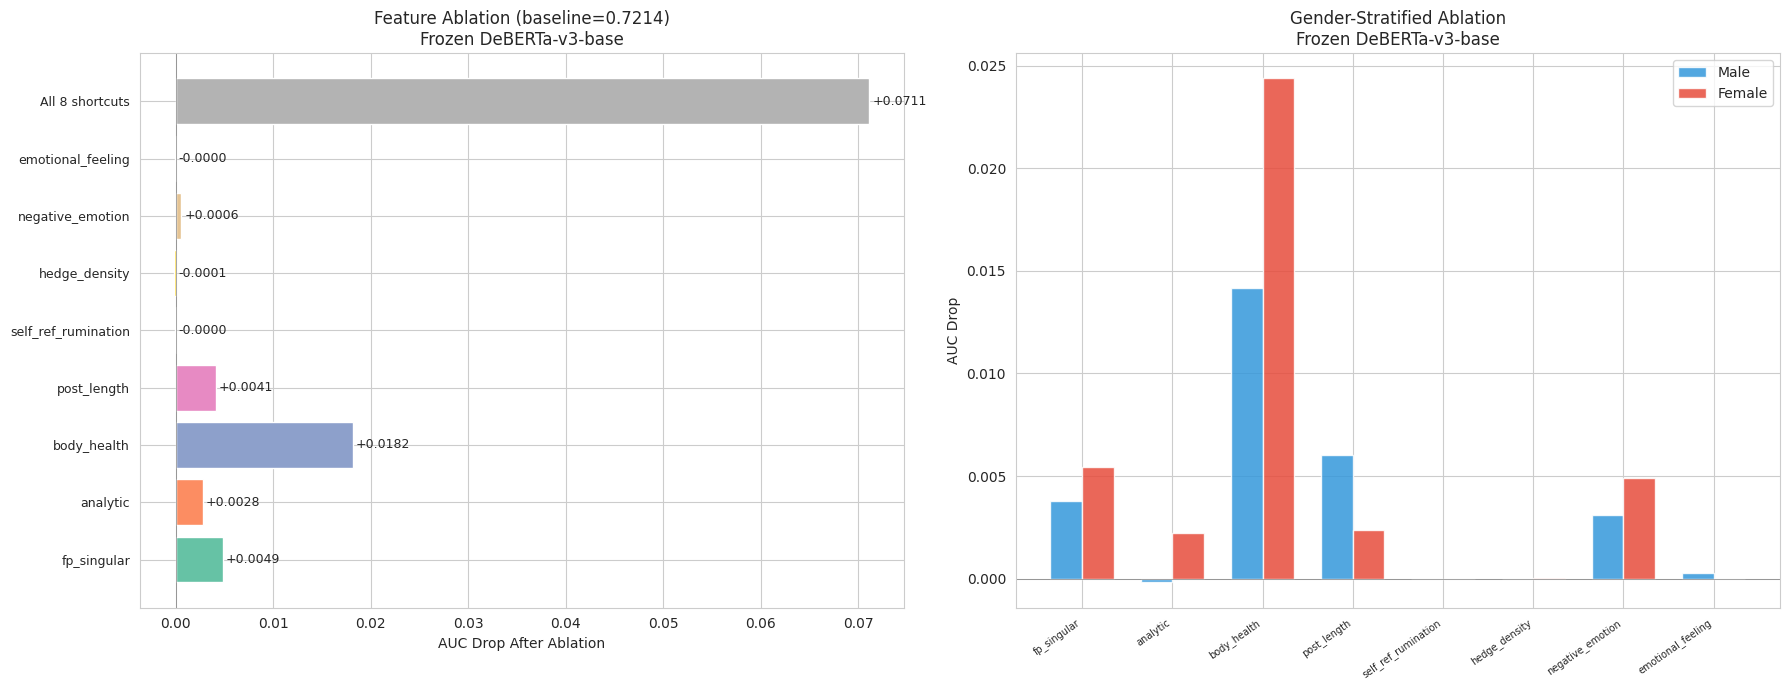

Saved → data/stage2_deberta/frozen/ablation_analysis.png

=== PART A SUMMARY (Frozen DeBERTa-v3-base) ===
  ★ fp_singular                AUC=0.948  R²=0.7656
  ★ analytic                   AUC=0.927  R²=0.7140
  ★ body_health                AUC=0.810  R²=0.4252
  ★ post_length                AUC=0.998  R²=0.4802
  ★ self_ref_rumination        AUC=0.894  R²=0.2753
  ★ hedge_density              AUC=0.804  R²=0.3372
  ★ negative_emotion           AUC=0.881  R²=0.2432
  ★ emotional_feeling          AUC=0.812  R²=0.3967
  ◇ cogproc                    AUC=0.871  R²=0.6106
  ◇ clout                      AUC=0.887  R²=0.5148
  gender AUC=0.864 | label AUC=0.798


In [11]:
ablation_df_frozen, strat_df_frozen, baseline_auc_frozen, aucs_all_frozen, drop_all_frozen = \
    run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL)

plot_ablation(ablation_df_frozen, strat_df_frozen, baseline_auc_frozen, drop_all_frozen,
              SHORTCUT_FEATURES, 'Frozen DeBERTa-v3-base',
              save_path=f'{OUT_FROZEN}/ablation_analysis.png')
ablation_df_frozen.to_csv(f'{OUT_FROZEN}/ablation_results.csv', index=False)
strat_df_frozen.to_csv(f'{OUT_FROZEN}/gender_stratified_ablation.csv', index=False)

print("\n=== PART A SUMMARY (Frozen DeBERTa-v3-base) ===")
for _, row in probe_df_frozen.iterrows():
    tag = '★' if row['role']=='shortcut' else '◇'
    print(f"  {tag} {row['feature']:25s}  AUC={row['probe_AUC_median_split']:.3f}  R²={row['probe_R2']:.4f}")
print(f"  gender AUC={aucs_g_frozen.mean():.3f} | label AUC={aucs_l_frozen.mean():.3f}")

---
# Part B — Fine-tuned DeBERTa-v3-base

Fine-tune for `text → binary_label` classification (80/20 stratified split),
then re-run all probing analyses on the encoder embeddings.

In [12]:
# DeBERTa-v3 fine-tune hyperparams. Aligned with MentalRoBERTa recipe.
BATCH_SIZE_FT = 32   # single GPU + fp16 has the headroom (was 16 under 4-GPU DP)
NUM_EPOCHS    = 3
LEARNING_RATE = 2e-5

train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42,
    stratify=df['binary_label'].values,
)
print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_hf_dataset(indices):
    sub = df.iloc[indices]
    return Dataset.from_dict({'text': sub['text'].tolist(), 'label': sub['binary_label'].tolist()})

def tokenize(batch):
    return tokenizer_ft(batch['text'], truncation=True, max_length=MAX_LEN)

train_ds = make_hf_dataset(train_idx).map(tokenize, batched=True, remove_columns=['text'])
val_ds   = make_hf_dataset(val_idx).map(tokenize,   batched=True, remove_columns=['text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)
print("Datasets tokenised.")

Train: 25,760  |  Val: 6,440


Map:   0%|          | 0/25760 [00:00<?, ? examples/s]

Map:   0%|          | 0/6440 [00:00<?, ? examples/s]

Datasets tokenised.


In [14]:
# Model loads as fp32 MASTER weights (deberta-v3 config defaults to fp16, which
# overflows under AdamW with no GradScaler — see git history). Keep dtype=fp32.
ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, ignore_mismatched_sizes=True, dtype=torch.float32
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs > 0.5).astype(int)
    return {'roc_auc': roc_auc_score(labels, probs), 'f1': f1_score(labels, preds)}

# SPEED: proper AMP mixed precision.
#   fp16=True  -> autocast forward in fp16 (V100 tensor cores, ~1.7x) while the
#                 fp32 master weights above + Trainer's GradScaler keep it stable.
#                 (This is safe ONLY because weights are fp32; raw fp16 weights NaN.)
#   train_sampling_strategy='group_by_length' -> posts span 29..38k chars; batch
#                 similar lengths so dynamic padding stops wasting compute padding
#                 short posts up to long ones. (transformers v5 renamed the old
#                 group_by_length=True flag to this train_sampling_strategy choice.)
#   dataloader_num_workers -> parallel collation so the GPU isn't input-starved.
# If AMP ever NaNs over a full run, fall back to fp16=False (validated stable @ ~41 samp/s).
training_args = TrainingArguments(
    output_dir=FT_MODEL_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_FT,
    per_device_eval_batch_size=64,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.10,
    max_grad_norm=1.0,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=False,
    logging_steps=50,
    fp16=True,
    train_sampling_strategy='group_by_length',
    dataloader_num_workers=4,
    dataloader_pin_memory=True,
    seed=42,
    report_to='none',
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print(f"Fine-tuning {MODEL_NAME} for {NUM_EPOCHS} epochs …")
trainer.train()

# Sanity check: surface per-epoch eval AUC. If first-epoch AUC is below ~0.6 or F1=0,
# the model failed to learn — stop before extracting embeddings.
print("\nPer-epoch eval log:")
best_auc, best_ckpt = 0.0, None
for entry in trainer.state.log_history:
    if 'eval_roc_auc' in entry:
        print(f"  epoch={entry['epoch']:.1f}  loss={entry.get('eval_loss', float('nan')):.4f}  "
              f"auc={entry['eval_roc_auc']:.4f}  f1={entry.get('eval_f1', float('nan')):.4f}")
        if entry['eval_roc_auc'] > best_auc:
            best_auc = entry['eval_roc_auc']
            best_ckpt = entry['epoch']
print(f"\nBest epoch: {best_ckpt} (eval_AUC={best_auc:.4f})")
assert best_auc > 0.70, (
    f"Fine-tune failed: best eval_AUC={best_auc:.4f} (<0.70). "
    "Retune hyperparameters before extracting embeddings."
)

val_results = trainer.evaluate()
print(f"\nFinal validation: {val_results}")

trainer.save_model(FT_MODEL_DIR)
tokenizer_ft.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias          

Fine-tuning microsoft/deberta-v3-base for 3 epochs …


Epoch,Training Loss,Validation Loss


OutOfMemoryError: Caught OutOfMemoryError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/gpfs/automountdir/gpfs/homes/SEAS/home/g21775526/code/mh-shortcut-learning/.venv/lib/python3.13/site-packages/torch/nn/parallel/parallel_apply.py", line 96, in _worker
    output = module(*input, **kwargs)
  File "/gpfs/automountdir/gpfs/homes/SEAS/home/g21775526/code/mh-shortcut-learning/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py", line 1739, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/gpfs/automountdir/gpfs/homes/SEAS/home/g21775526/code/mh-shortcut-learning/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py", line 1750, in _call_impl
    return forward_call(*args, **kwargs)
  File "/gpfs/automountdir/gpfs/homes/SEAS/home/g21775526/code/mh-shortcut-learning/.venv/lib/python3.13/site-packages/transformers/models/deberta_v2/modeling_deberta_v2.py", line 1059, in f

In [ ]:

trainer.save_model(FT_MODEL_DIR)
tokenizer_ft.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

In [ ]:
encoder_ft = AutoModel.from_pretrained(FT_MODEL_DIR, dtype=torch.float32).to(DEVICE).eval()
tokenizer_ft_loaded = AutoTokenizer.from_pretrained(FT_MODEL_DIR)

if N_GPUS > 1:
    encoder_ft = nn.DataParallel(encoder_ft)
    print(f"  Wrapped in DataParallel across {N_GPUS} GPUs")

print(f"Extracting [CLS] embeddings (fine-tuned) for {len(df):,} posts …")
X_cls_ft = extract_cls_embeddings(df['text'].tolist(), encoder_ft, tokenizer_ft_loaded)
print(f"Shape: {X_cls_ft.shape}")
np.save(f'{OUT_FT}/cls_embeddings.npy', X_cls_ft)
print(f"Saved → {OUT_FT}/cls_embeddings.npy")

## B1 — Probing Classifiers (Fine-tuned)

In [ ]:
print("Running probing on fine-tuned DeBERTa-v3 [CLS] …")
probe_df_ft, aucs_g_ft, aucs_l_ft, _ = run_probing(
    X_cls_ft, df, PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
    GENDER_COL, mf_mask, df_mf
)
probe_df_ft

In [ ]:
plot_probing(probe_df_ft, aucs_g_ft, aucs_l_ft,
             PROBE_FEATURES, SHORTCUT_FEATURES, CONTROL_FEATURES,
             title_suffix='Fine-tuned DeBERTa-v3-base',
             save_path=f'{OUT_FT}/probing_results.png')
probe_df_ft.to_csv(f'{OUT_FT}/probing_results.csv', index=False)

## B2 — Layer-wise Probing (Fine-tuned)

In [ ]:
print(f"Extracting all-layer [CLS] (fine-tuned) for {len(df):,} posts …")
all_layer_cls_ft = extract_cls_all_layers(df['text'].tolist(), encoder_ft, tokenizer_ft_loaded)
print(f"Got {len(all_layer_cls_ft)} layers")

In [ ]:
print("Running layer-wise probing (fine-tuned) …")
layer_probe_df_ft, layer_names_ft = run_layerwise_probing(
    all_layer_cls_ft, targets, PROBE_FEATURES,
    SHORTCUT_FEATURES, CONTROL_FEATURES, mf_idx_arr
)
pivot_ft = layer_probe_df_ft.pivot(index='target', columns='layer_name', values='AUC')
print(pivot_ft[layer_names_ft].round(3).to_string())

In [ ]:
plot_layerwise(layer_probe_df_ft, layer_names_ft,
               SHORTCUT_FEATURES, CONTROL_FEATURES, all_targets_ordered,
               title_suffix='Fine-tuned DeBERTa-v3-base',
               save_prefix=f'{OUT_FT}/layerwise')
layer_probe_df_ft.to_csv(f'{OUT_FT}/layerwise_probing.csv', index=False)

## B3 — SHAP (same feature model, saved to finetuned dir)

In [ ]:
np.save(f'{OUT_FT}/shap_values.npy', shap_values)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
axes[0].barh(range(len(order)), mean_abs[order], color=bar_c, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP|'); axes[0].set_title('SHAP Feature Importance')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx]+0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)
axes[1].bar(x-w/2, shap_df[shap_df['gender']=='male'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x+w/2, shap_df[shap_df['gender']=='female'][SHORTCUT_FEATURES].abs().mean().values,
            w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[1].set_ylabel('Mean |SHAP|'); axes[1].set_title('SHAP by Gender'); axes[1].legend()
axes[2].bar(x-w/2, pos_s.values, w, label='Positive', color='#e74c3c', alpha=0.85)
axes[2].bar(x+w/2, neg_s.values, w, label='Negative', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[2].set_ylabel('Mean SHAP (signed)'); axes[2].set_title('SHAP by Label')
axes[2].axhline(0, color='black', linewidth=0.5); axes[2].legend()
plt.tight_layout()
plt.savefig(f'{OUT_FT}/shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show(); print(f"Saved → {OUT_FT}/shap_analysis.png")

## B4 — Feature Ablation (Fine-tuned)

In [ ]:
ablation_df_ft, strat_df_ft, baseline_auc_ft, aucs_all_ft, drop_all_ft = \
    run_ablation(df, ALL_18_FEATURES, SHORTCUT_FEATURES, GENDER_COL)

plot_ablation(ablation_df_ft, strat_df_ft, baseline_auc_ft, drop_all_ft,
              SHORTCUT_FEATURES, 'Fine-tuned DeBERTa-v3-base',
              save_path=f'{OUT_FT}/ablation_analysis.png')
ablation_df_ft.to_csv(f'{OUT_FT}/ablation_results.csv', index=False)
strat_df_ft.to_csv(f'{OUT_FT}/gender_stratified_ablation.csv', index=False)

---
# Summary: Frozen vs Fine-tuned DeBERTa-v3-base

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
all_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']

def get_aucs(probe_df, aucs_g, aucs_l):
    return [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
            for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]

aucs_frz = get_aucs(probe_df_frozen, aucs_g_frozen, aucs_l_frozen)
aucs_ftn = get_aucs(probe_df_ft, aucs_g_ft, aucs_l_ft)

x = np.arange(len(all_labels)); w = 0.35
axes[0].barh(x-w/2, aucs_frz, w, label='Frozen',     color='#3498db', alpha=0.85)
axes[0].barh(x+w/2, aucs_ftn, w, label='Fine-tuned', color='#e74c3c', alpha=0.85)
axes[0].set_yticks(x); axes[0].set_yticklabels(all_labels, fontsize=10)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Probe AUC (5-fold CV)')
axes[0].set_title('Probe AUC: Frozen vs Fine-tuned\nDeBERTa-v3-base', fontweight='bold')
axes[0].legend()

r2_frz = probe_df_frozen['probe_R2'].values
r2_ftn = probe_df_ft['probe_R2'].values
x2 = np.arange(len(PROBE_FEATURES))
axes[1].barh(x2-w/2, r2_frz, w, label='Frozen',     color='#3498db', alpha=0.85)
axes[1].barh(x2+w/2, r2_ftn, w, label='Fine-tuned', color='#e74c3c', alpha=0.85)
axes[1].set_yticks(x2); axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
axes[1].set_xlabel('Regression Probe R²')
axes[1].set_title('Probe R²: Frozen vs Fine-tuned\nDeBERTa-v3-base', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUT_ROOT}/comparison_frozen_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_ROOT}/comparison_frozen_vs_finetuned.png")

In [ ]:
print("=" * 65)
print("FINAL SUMMARY — DeBERTa-v3-base (Frozen vs Fine-tuned)")
print("=" * 65)

header = f"{'Feature':25s}  {'Frz AUC':>8}  {'FT AUC':>7}  {'ΔAUC':>6}  {'Frz R²':>7}  {'FT R²':>6}  {'ΔR²':>6}"
print(f"\n{header}")
print("-" * len(header))
for feat in PROBE_FEATURES:
    frz = probe_df_frozen[probe_df_frozen['feature']==feat].iloc[0]
    ft  = probe_df_ft[probe_df_ft['feature']==feat].iloc[0]
    da  = ft['probe_AUC_median_split'] - frz['probe_AUC_median_split']
    dr  = ft['probe_R2'] - frz['probe_R2']
    tag = '★' if frz['role']=='shortcut' else '◇'
    print(f"{tag} {feat:24s}  {frz['probe_AUC_median_split']:8.3f}  "
          f"{ft['probe_AUC_median_split']:7.3f}  {da:+6.3f}  "
          f"{frz['probe_R2']:7.4f}  {ft['probe_R2']:6.4f}  {dr:+6.4f}")

print(f"\n  Gender AUC : frozen={aucs_g_frozen.mean():.3f}  finetuned={aucs_g_ft.mean():.3f}  "
      f"Δ={aucs_g_ft.mean()-aucs_g_frozen.mean():+.3f}")
print(f"  Label  AUC : frozen={aucs_l_frozen.mean():.3f}  finetuned={aucs_l_ft.mean():.3f}  "
      f"Δ={aucs_l_ft.mean()-aucs_l_frozen.mean():+.3f}")
print(f"\nFiles saved to: {OUT_ROOT}/")